# Data Classification Using Artifical Intelligence


### This notebook implements a supervised machine learning pipeline to transition from manual, rule-based heuristics to algorithmic classification using the baseline Iris Flower Dataset.
### Following the core structural principles outlined by DecodeLabs, the workflow covers data ingestion, random shuffling to prevent order bias, and standardized feature scaling.
### By applying the K-Nearest Neighbors (KNN) algorithm, the model learns to identify complex decision boundaries across multi-dimensional measurements. Final predictive performance is rigorously evaluated using metrics including the F1-Score and an intuitive Confusion Matrix visualization.

### Step 1 : Environment Setup & Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# 1. Load the Iris dataset 
file_path = '/kaggle/input/datasets/arshid/iris-flower-dataset/IRIS.csv'
df = pd.read_csv(file_path)

# Preview the dataset structural layout
print("--- Dataset Summary ---")
print(df.info())
print("\n--- First 5 Samples ---")
print(df.head())

print("\nClass Distribution Counts:")
print(df['species'].value_counts())

--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

--- First 5 Samples ---
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Class Distribution Counts:
species
Iris-setosa        50
Iris-versicolor  

### Step 2 : Feature-Target Segregation & Data Splitting

In [3]:
# 2. Separate independent features (X) and dependent target label (y)
X = df.drop(columns=['species'])
y = df['species']

# Split into Training Set (80%) and Test Set (20%) with shuffling enabled
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    shuffle=True, 
    random_state=42,
    stratify=y
)

print(f"Training feature set dimensions: {X_train.shape}")
print(f"Testing feature set dimensions: {X_test.shape}")

Training feature set dimensions: (120, 4)
Testing feature set dimensions: (30, 4)


### Step 3 : Feature Scaling (The Gatekeeper Rule)

In [4]:
# 3. Apply StandardScaler mapping transformation
scaler = StandardScaler()

# Fit only on training features to prevent target leakage.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify the feature properties.
print(f"Scaled Training Mean (per feature): {np.round(X_train_scaled.mean(axis=0), 2)}")
print(f"Scaled Training Variance (per feature): {np.round(X_train_scaled.var(axis=0), 2)}")

Scaled Training Mean (per feature): [-0.  0. -0.  0.]
Scaled Training Variance (per feature): [1. 1. 1. 1.]


### Step 4 : Training the KNN Classification Model

In [5]:
# 4. Initialize and train the K-Nearest Neighbors Classifier.
# We pick k=5 as an algorithmic baseline.
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

print("KNN Model training complete.")

KNN Model training complete.


### Step 5: Model Evaluation (Confusion Matrix & F1-Score)

Validation Accuracy: 93.33%
Macro F1-Score: 0.9327

--- Detailed Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



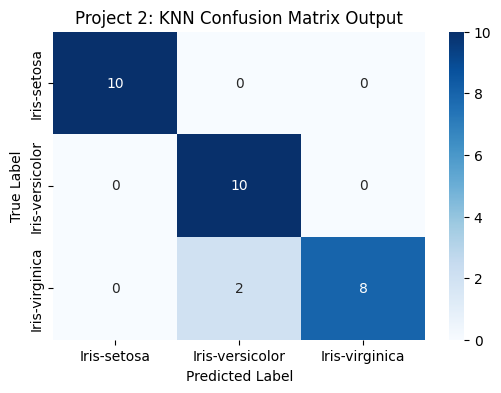

In [6]:
# 5. Generate target predictions from the test validation data
y_pred = knn_model.predict(X_test_scaled)

# Calculate performance metrics
overall_accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Validation Accuracy: {overall_accuracy * 100:.2f}%")
print(f"Macro F1-Score: {macro_f1:.4f}\n")

# Display complete classification reports containing per-class precision, recall, and F1-score
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# Generate the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the Confusion Matrix using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=knn_model.classes_, 
    yticklabels=knn_model.classes_
)
plt.title('Project 2: KNN Confusion Matrix Output')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()